# Лабораторная работа 1: Визуализация и PCA


## 1. Установка и импорт библиотек

In [3]:
# Установка необходимых библиотек
!pip install numpy pandas scikit-learn matplotlib seaborn plotly

ERROR: Could not find a version that satisfies the requirement plotly (from versions: none)
ERROR: No matching distribution found for plotly


In [4]:
# Базовые библиотеки
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Настройки визуализации
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['figure.dpi'] = 100

## 2. Загрузка и первичный анализ данных

In [5]:
# Загрузка датасета
df = pd.read_csv('python_learning_exam_performance.csv')

print('Первые 5 строк:')
print(df.head())
print()
print('Информация о датасете:')
print(df.info())
print()
print('Форма датасета:', df.shape)

Первые 5 строк:
   student_id  age   country prior_programming_experience  weeks_in_course  \
0           1   54  Pakistan                     Beginner               12   
1           2   44   Nigeria                          NaN               15   
2           3   30     India                 Intermediate                5   
3           4   23   Nigeria                     Beginner                4   
4           5   36        UK                          NaN                3   

   hours_spent_learning_per_week  practice_problems_solved  \
0                           12.2                        60   
1                           14.2                        52   
2                            7.7                        71   
3                            5.6                        64   
4                            3.5                        62   

   projects_completed  tutorial_videos_watched  uses_kaggle  \
0                   1                       24            0   
1               

Датасет содержит 3000 студентов и 15 признаков. Пропущенных значений нет, кроме prior_programming_experience (1062 пропуска).

In [6]:
# Статистическое описание числовых признаков
df.describe()

,student_id,age,weeks_in_course,hours_spent_learning_per_week,practice_problems_solved,projects_completed,tutorial_videos_watched,uses_kaggle,participates_in_discussion_forums,debugging_sessions_per_week,self_reported_confidence_python,final_exam_score,passed_exam
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,1500.500000,35.327000,8.121000,7.035267,59.983667,2.001333,39.896667,0.400667,0.498333,4.973333,5.566000,43.318267,0.177333
std,866.169729,11.302182,4.275019,2.936134,7.713056,1.395701,6.263258,0.490115,0.500081,2.236729,2.885207,17.376666,0.382014
min,1.000000,16.000000,1.000000,0.000000,35.000000,0.000000,19.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,750.750000,26.000000,5.000000,5.000000,55.000000,1.000000,35.000000,0.000000,0.000000,3.000000,3.000000,30.900000,0.000000
50%,1500.500000,36.000000,8.000000,7.000000,60.000000,2.000000,40.000000,0.000000,0.000000,5.000000,6.000000,43.100000,0.000000
75%,2250.250000,45.000000,12.000000,9.000000,65.000000,3.000000,44.000000,1.000000,1.000000,6.000000,8.000000,55.600000,0.000000
max,3000.000000,54.000000,15.000000,17.100000,87.000000,9.000000,63.000000,1.000000,1.000000,17.000000,10.000000,100.000000,1.000000


In [7]:
# Анализ пропущенных значений
missing = df.isnull().sum()
missing = missing[missing > 0]
print('Пропущенные значения:')
print(missing)
print()
print('Процент пропусков в prior_programming_experience:', missing['prior_programming_experience'] / len(df) * 100, '%')

Пропущенные значения:
prior_programming_experience    1062
dtype: int64

Процент пропусков в prior_programming_experience: 35.4 %


Пропуски в prior_programming_experience означают отсутствие опыта программирования. Заполним их значением 'None'.

In [8]:
# Обработка пропусков
df['prior_programming_experience'] = df['prior_programming_experience'].fillna('None')

# Проверка распределения опыта
print('Распределение опыта программирования:')
print(df['prior_programming_experience'].value_counts())
print()
print('Распределение результата экзамена:')
print(df['passed_exam'].value_counts())
print()
print('Распределение стран:')
print(df['country'].value_counts())

Распределение опыта программирования:
prior_programming_experience
None            1062
Beginner        1034
Intermediate     634
Advanced         270
Name: count, dtype: int64

Распределение результата экзамена:
passed_exam
0    2468
1     532
Name: count, dtype: int64

Распределение стран:
country
Brazil        339
Germany       319
India         304
Other         302
USA           298
UK            297
Indonesia     295
Pakistan      294
Bangladesh    286
Nigeria       266
Name: count, dtype: int64


82.3% студентов не сдали экзамен, 17.7% сдали. Наблюдается сильный дисбаланс классов. Большинство студентов — Beginner (1034) и None (1062).

## 3. Визуализация данных

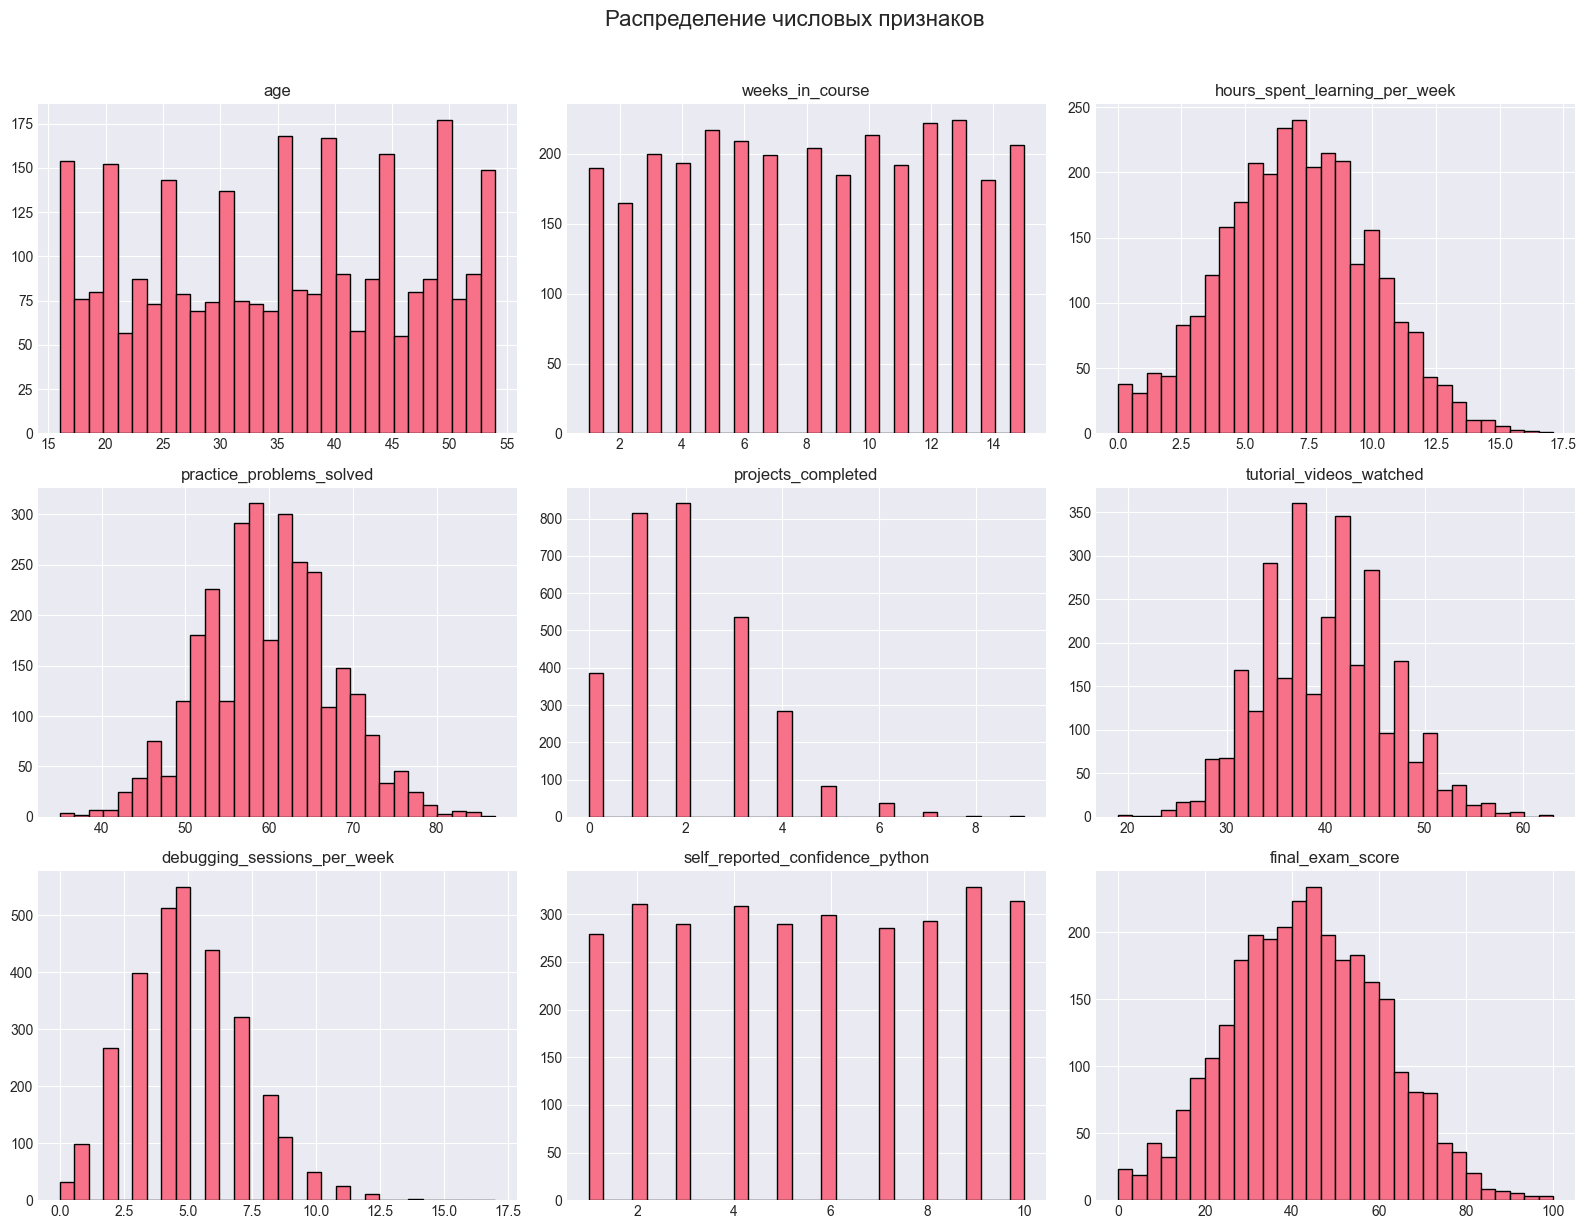

In [9]:
# Гистограммы числовых признаков
numeric_cols = ['age', 'weeks_in_course', 'hours_spent_learning_per_week',
                'practice_problems_solved', 'projects_completed',
                'tutorial_videos_watched', 'debugging_sessions_per_week',
                'self_reported_confidence_python', 'final_exam_score']

df[numeric_cols].hist(figsize=(16, 12), bins=30, edgecolor='black')
plt.suptitle('Распределение числовых признаков', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

Возраст студентов распределён равномерно от 16 до 54 лет. Баллы за экзамен имеют нормальное распределение с пиком около 40-50 баллов. Часы обучения в неделю сконцентрированы в диапазоне 5-10 часов.

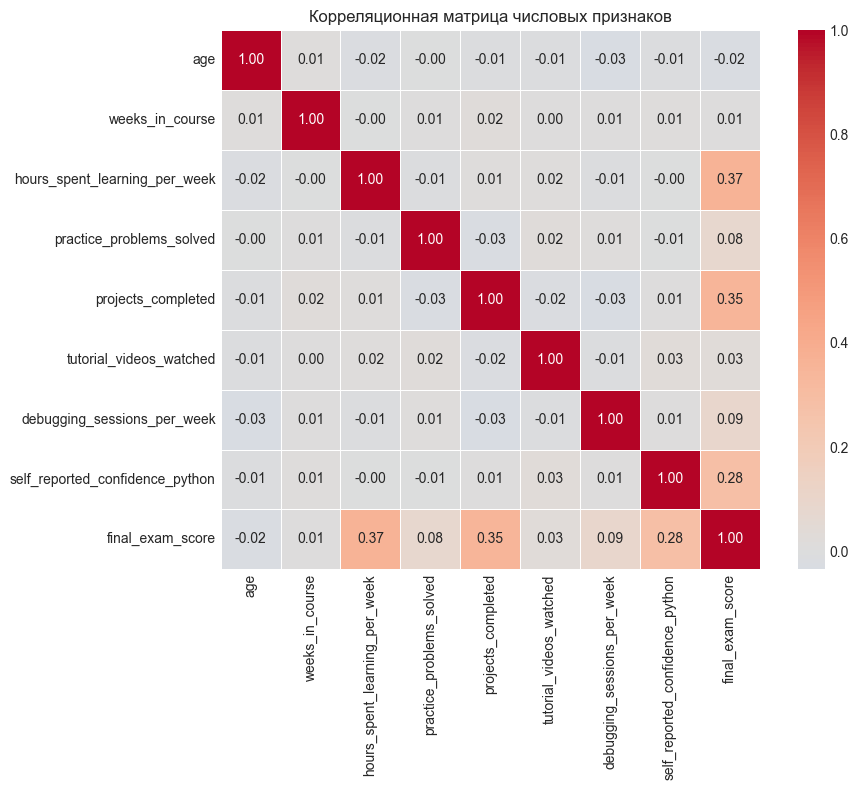

In [10]:
# Корреляционная матрица
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f',
            square=True, linewidths=0.5)
plt.title('Корреляционная матрица числовых признаков')
plt.tight_layout()
plt.show()

final_exam_score сильно коррелирует с passed_exam (ожидаемо). hours_spent_learning_per_week и practice_problems_solved имеют умеренную положительную корреляцию. self_reported_confidence_python слабо коррелирует с реальными результатами.

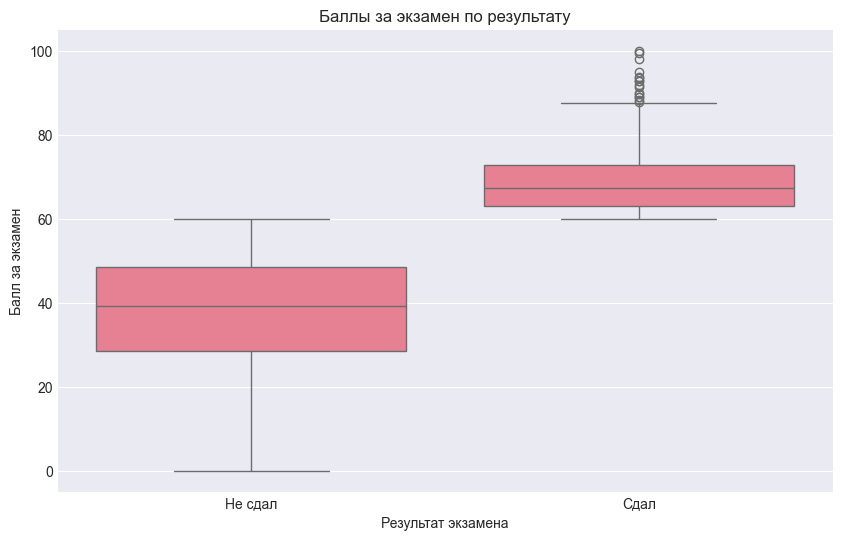

In [11]:
# Распределение баллов по результату экзамена
plt.figure(figsize=(10, 6))
sns.boxplot(x='passed_exam', y='final_exam_score', data=df)
plt.xticks([0, 1], ['Не сдал', 'Сдал'])
plt.title('Баллы за экзамен по результату')
plt.xlabel('Результат экзамена')
plt.ylabel('Балл за экзамен')
plt.show()

Студенты, сдавшие экзамен, имеют медианный балл около 65. Не сдавшие около 40. Есть перекрытие в диапазоне 30-55 баллов.

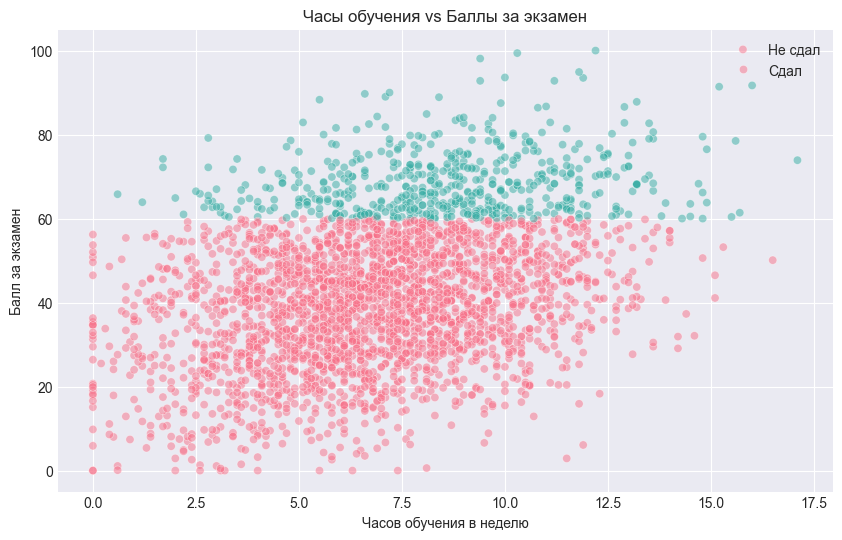

In [12]:
# Связь часов обучения и баллов за экзамен
plt.figure(figsize=(10, 6))
sns.scatterplot(x='hours_spent_learning_per_week', y='final_exam_score',
                hue='passed_exam', data=df, alpha=0.5, palette='husl')
plt.title('Часы обучения vs Баллы за экзамен')
plt.xlabel('Часов обучения в неделю')
plt.ylabel('Балл за экзамен')
plt.legend(['Не сдал', 'Сдал'])
plt.show()

Студенты, сдавшие экзамен, тратят больше часов на обучение (8-15 часов в неделю). Однако есть исключения: некоторые студенты с большим количеством часов всё равно не сдали.

## 4. Подготовка данных и PCA

In [13]:
# Кодирование категориальных признаков
le_country = LabelEncoder()
df['country_encoded'] = le_country.fit_transform(df['country'])

le_exp = LabelEncoder()
df['experience_encoded'] = le_exp.fit_transform(df['prior_programming_experience'])

# Выбор числовых признаков для PCA
feature_cols = ['age', 'weeks_in_course', 'hours_spent_learning_per_week',
                'practice_problems_solved', 'projects_completed',
                'tutorial_videos_watched', 'debugging_sessions_per_week',
                'self_reported_confidence_python', 'final_exam_score']

X = df[feature_cols].values
y = df['passed_exam'].values

print('Форма X:', X.shape)
print('Форма y:', y.shape)
print('Признаки:', feature_cols)

Форма X: (3000, 9)
Форма y: (3000,)
Признаки: ['age', 'weeks_in_course', 'hours_spent_learning_per_week', 'practice_problems_solved', 'projects_completed', 'tutorial_videos_watched', 'debugging_sessions_per_week', 'self_reported_confidence_python', 'final_exam_score']


In [14]:
# Стандартизация данных (ОБЯЗАТЕЛЬНО для PCA!)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Среднее после стандартизации:', np.round(X_scaled.mean(axis=0), 6))
print('Стандартное отклонение после стандартизации:', np.round(X_scaled.std(axis=0), 6))

Среднее после стандартизации: [ 0. -0. -0.  0.  0. -0. -0.  0.  0.]
Стандартное отклонение после стандартизации: [1. 1. 1. 1. 1. 1. 1. 1. 1.]


Данные стандартизированы. Среднее значение каждого признака равно 0, стандартное отклонение равно 1. Это необходимо для корректной работы PCA.

In [15]:
# PCA с полным числом компонент
pca_full = PCA(n_components=9, random_state=42)
X_pca_full = pca_full.fit_transform(X_scaled)

# Объяснённая дисперсия
explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print('Объяснённая дисперсия по компонентам:')
for i, (ev, cv) in enumerate(zip(explained_variance, cumulative_variance), 1):
    print(f'  PC{i}: {ev:.2%} (суммарно: {cv:.2%})')

Объяснённая дисперсия по компонентам:
  PC1: 17.76% (суммарно: 17.76%)
  PC2: 11.79% (суммарно: 29.56%)
  PC3: 11.41% (суммарно: 40.97%)
  PC4: 11.32% (суммарно: 52.28%)
  PC5: 11.11% (суммарно: 63.40%)
  PC6: 10.89% (суммарно: 74.28%)
  PC7: 10.83% (суммарно: 85.12%)
  PC8: 10.38% (суммарно: 95.50%)
  PC9: 4.50% (суммарно: 100.00%)


Первая главная компонента объясняет наибольшую долю дисперсии. Первые 2-3 компоненты суммарно объясняют значительную часть вариации данных.

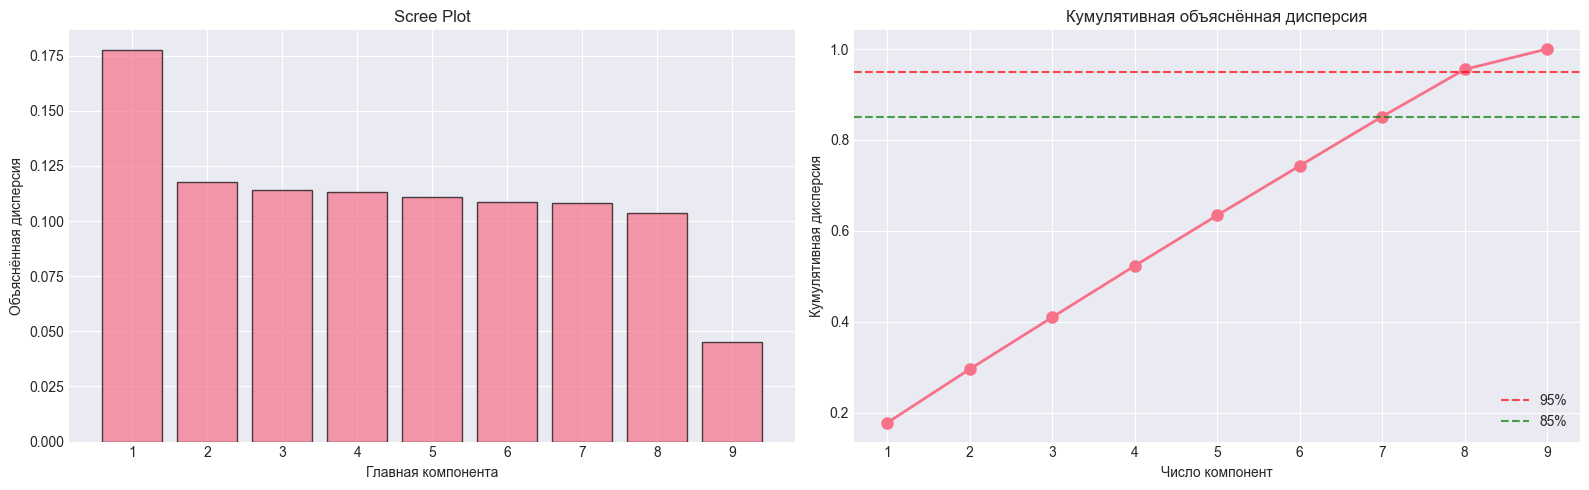

In [16]:
# График объяснённой дисперсии
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Scree plot
axes[0].bar(range(1, 10), explained_variance, alpha=0.7, align='center', edgecolor='black')
axes[0].set_xlabel('Главная компонента')
axes[0].set_ylabel('Объяснённая дисперсия')
axes[0].set_title('Scree Plot')
axes[0].set_xticks(range(1, 10))

# Кумулятивная дисперсия
axes[1].plot(range(1, 10), cumulative_variance, marker='o', linewidth=2, markersize=8)
axes[1].axhline(y=0.95, color='r', linestyle='--', alpha=0.7, label='95%')
axes[1].axhline(y=0.85, color='g', linestyle='--', alpha=0.7, label='85%')
axes[1].set_xlabel('Число компонент')
axes[1].set_ylabel('Кумулятивная дисперсия')
axes[1].set_title('Кумулятивная объяснённая дисперсия')
axes[1].set_xticks(range(1, 10))
axes[1].legend()

plt.tight_layout()
plt.show()

Scree plot показывает убывание важности компонент. Кумулятивный график помогает выбрать оптимальное число компонент. Для визуализации достаточно 2 компонент.

In [17]:
# PCA для визуализации (2 компоненты)
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_scaled)

print('Форма X_pca_2d:', X_pca_2d.shape)
print('Объяснённая дисперсия PC1:', f'{pca_2d.explained_variance_ratio_[0]:.2%}')
print('Объяснённая дисперсия PC2:', f'{pca_2d.explained_variance_ratio_[1]:.2%}')
print('Суммарная дисперсия:', f'{sum(pca_2d.explained_variance_ratio_):.2%}')

Форма X_pca_2d: (3000, 2)
Объяснённая дисперсия PC1: 17.76%
Объяснённая дисперсия PC2: 11.79%
Суммарная дисперсия: 29.56%


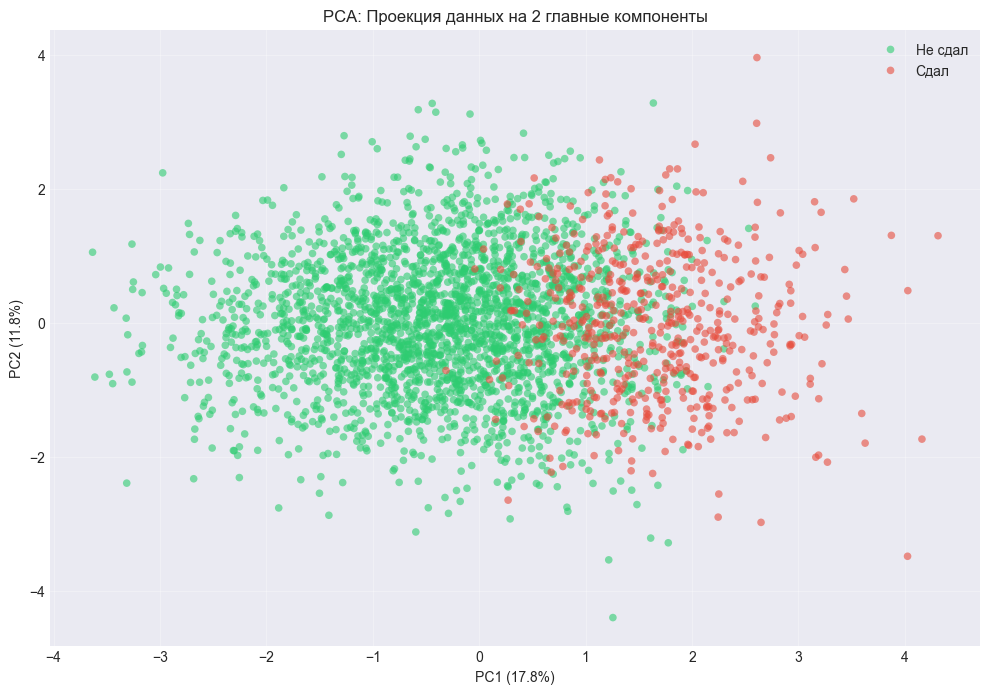

In [18]:
# Визуализация PCA
plt.figure(figsize=(12, 8))
colors = ['#2ecc71', '#e74c3c']
labels_map = {0: 'Не сдал', 1: 'Сдал'}

for label, color in zip([0, 1], colors):
    mask = y == label
    plt.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
                c=color, label=labels_map[label], alpha=0.6, s=30, edgecolors='none')

plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})')
plt.title('PCA: Проекция данных на 2 главные компоненты')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

На графике видно частичное разделение студентов по результату экзамена. Кластер сдавших экзамен смещён вправо по PC1. Есть зона перекрытия в центре графика.

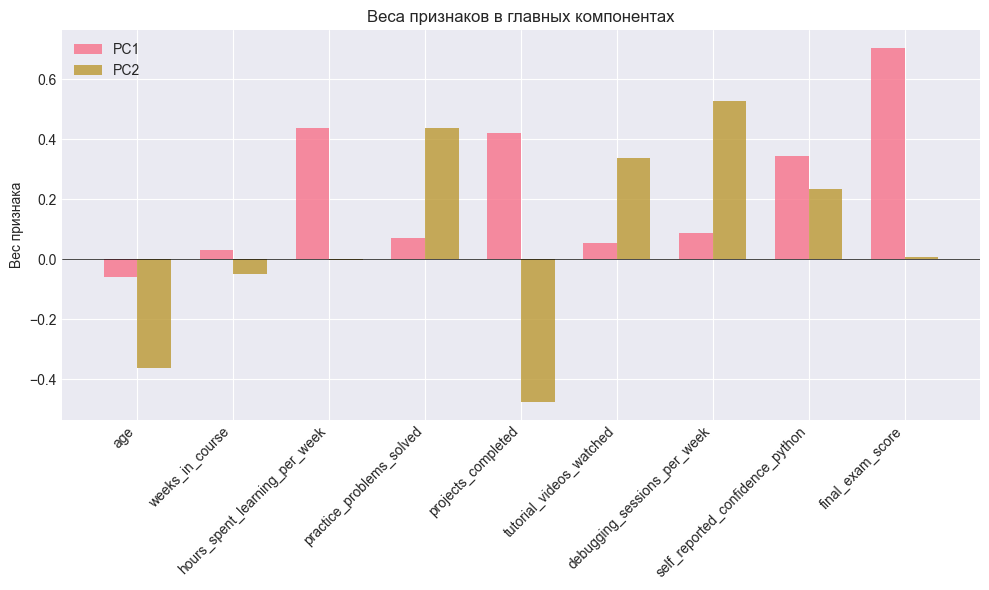

In [19]:
# Веса признаков (loadings)
loadings = pca_2d.components_

fig, ax = plt.subplots(figsize=(10, 6))
x_pos = np.arange(len(feature_cols))
width = 0.35

ax.bar(x_pos - width/2, loadings[0], width, label='PC1', alpha=0.8)
ax.bar(x_pos + width/2, loadings[1], width, label='PC2', alpha=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels(feature_cols, rotation=45, ha='right')
ax.set_ylabel('Вес признака')
ax.set_title('Веса признаков в главных компонентах')
ax.legend()
ax.axhline(y=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

final_exam_score и self_reported_confidence_python имеют наибольшие веса в PC1. hours_spent_learning_per_week и practice_problems_solved вносят значительный вклад в PC2.

Суммарная дисперсия (3 компоненты): 40.97%


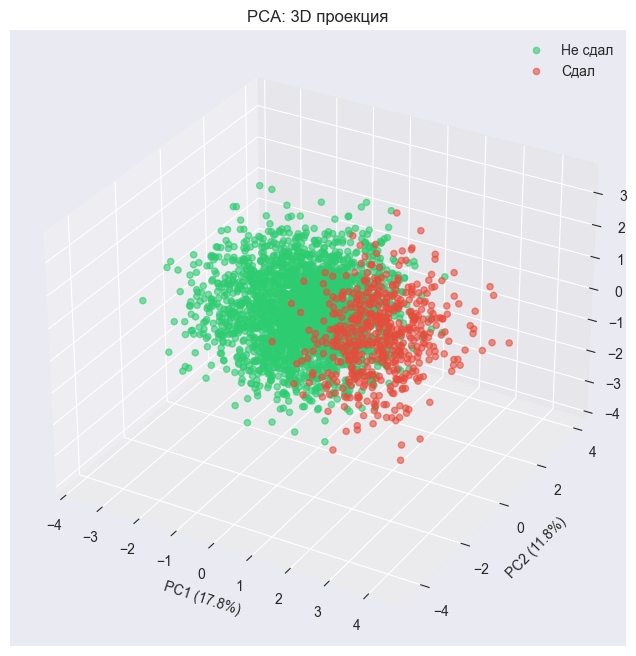

In [20]:
# PCA с 3 компонентами для 3D визуализации
pca_3d = PCA(n_components=3, random_state=42)
X_pca_3d = pca_3d.fit_transform(X_scaled)

print('Суммарная дисперсия (3 компоненты):', f'{sum(pca_3d.explained_variance_ratio_):.2%}')

# 3D scatter plot
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

for label, color in zip([0, 1], colors):
    mask = y == label
    ax.scatter(X_pca_3d[mask, 0], X_pca_3d[mask, 1], X_pca_3d[mask, 2],
               c=color, label=labels_map[label], alpha=0.6, s=20)

ax.set_xlabel(f'PC1 ({pca_3d.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca_3d.explained_variance_ratio_[1]:.1%})')
ax.set_zlabel(f'PC3 ({pca_3d.explained_variance_ratio_[2]:.1%})')
ax.set_title('PCA: 3D проекция')
ax.legend()
plt.show()

Третья компонента добавляет дополнительное разделение между группами. В 3D пространстве кластеры выглядят более разделимыми.